In [46]:
%matplotlib inline

In [ ]:
# Imports
import os
import pathlib
SALVUS_FLOW_SITE_NAME = os.environ.get("macbook") # Site name given in the installation of Salvus flow
PROJECT_DIR = "simulation_wavefield_moving_source_momentt"  

# Add code to keep .gitignore updated to ignore salvus files
gitignore_path = pathlib.Path("..") / ".gitignore"
with open(gitignore_path, "r+") as f:
    contents = f.read()
    if PROJECT_DIR not in contents:
        f.write(f"\n{PROJECT_DIR}/\n")


import numpy as np
import salvus.namespace as sn
import xarray as xr
import salvus.namespace as sn
from salvus.project.tools.processing import block_processing
from salvus.toolbox.helpers.wavefield_output import (
    WavefieldOutput,
    wavefield_output_to_xarray,
)
import matplotlib.pyplot as plt
from matplotlib import animation
import obspy

# For wavefield output code
from salvus.mesh.unstructured_mesh_utils import read_model_from_h5
from salvus.toolbox.helpers import wavefield_output

#for plotting of wiggles, traces 
from scipy import signal

# For animation plot
from IPython.display import HTML
from matplotlib.collections import PolyCollection
import threading
import matplotlib
matplotlib.use("Agg")
from scipy.interpolate import griddata

/var/folders/5f/g3nknsgx6q3f91j5rd12vp240000gn/T/ipykernel_4061/1256747711.py:40: MatplotlibDeprecationWarning: Auto-close()ing of figures upon backend switching is deprecated since 3.8 and will be removed in 3.10.  To suppress this warning, explicitly call plt.close('all') first.
  matplotlib.use("Agg")


In [48]:
# Setup of the model domain as a box (same as research module)
domain_2d = sn.domain.dim2.BoxDomain(x0=0, x1=300, y0=0, y1=3)
p = sn.Project.from_domain(path=PROJECT_DIR, domain=domain_2d, load_if_exists=True)

Accordion(children=(HTML(value='\n                <head>\n                <style>\n                td {\n     …

[2026-04-13 12:32:03,258] INFO: Loading project from simulation_wavefield_moving_source.


In [49]:

# Layered model setup according to mondaic docs
# Minimal and maximal x extent: same as domain box
x_min = 0.0
x_max = 300.0

# Defining extent of löayers (layers_x) and thickness / topography of layers (layers_y)
layers_x = [
    np.array([0.0, 300.0]),  # top boundary
    np.array([0.0, 300.0]),  # snow-air interface
    np.array([0.0, 300.0]),  # earth-snow interface 
    np.array([0.0, 300.0]),  # bottom boundary
]

layers_y = [
    np.array([3.0, 3.0]),        
    np.array([3*2/3, 3*2/3]),        
    np.array([3*1/3, 3*1/3]),        
    np.array([0.0, 0.0]),        
]

# Defining model parameters (vp, vs and rho) for earth, snow and air, earth and air velocities taken from https://pburnley.faculty.unlv.edu/GEOL452_652/seismology/notes/SeismicNotes10RVel.html
vp = np.array([2200, 300, 332])
#vs = np.array([0,0,0])
vs = np.array([880, 150,0])
rho = np.array([2000, 180, 1.2250])


interpolation_styles = ["linear"] * len(layers_x)


splines = sn.toolbox.get_interpolating_splines(
    layers_x, layers_y, kind=interpolation_styles
)

# # Plotting the layer boundaries to check if they are correct
# f = plt.figure(figsize=(10, 5))
# x_plot = np.linspace(x_min, x_max)
# for top, bot in splines:
#     plt.plot(x_plot, top(x_plot))
#     plt.plot(x_plot, bot(x_plot))

# plt.xlabel("x (m)")
# plt.ylabel("y (m)")
# plt.title("Interfaces")
# plt.ylim(0,1.5)

# Genetarte mesh
# Maximum frequency to resolve with elements_per_wavelength.
max_frequency = 50.0

# Print lenght of splines because of size mismatch between splines and vs
shp = len(splines)
print(shp)

slowest_velocities = np.array([
    880,   # earth
    150,   # snow
    150,   # air layer meshing controlled by snow below --> need this because else slowest_velocities gives an errror because it goes to infinity
])

# Generate the mesh
mesh, bnd = sn.toolbox.generate_mesh_from_splines_2d(
    x_min=0,
    x_max=x_max,
    splines=splines,
    elements_per_wavelength=2,
    maximum_frequency=max_frequency,
    use_refinements=True,
    slowest_velocities=slowest_velocities,
    # make very bottom boundary, very top (in x) and both sides in y absorbing
    absorbing_boundaries=(["x0", "x1", "y0", "y1"], 10.0), # Change this if different boundaries need to be absorbing CHECK 
)

mesh = np.sum(mesh)

# Add info about absorbing boundaries CHANGE DEPENDING ON WHICH BOUNDARIES NEED TO BE TRANSPARENT / ABSORBING
mesh.attach_global_variable("max_dist_ABC", bnd)
mesh.attach_global_variable("ABC_side_sets", ", ".join(["x0", "x1", "y0"]))
mesh.attach_global_variable("ABC_vel", float(min(vs[vs > 0])))
mesh.attach_global_variable("ABC_freq", max_frequency / 2.0)
mesh.attach_global_variable("ABC_nwave", 5.0)


# Attaching parameters (vp,vs,rho) to mesh 
nodes = mesh.get_element_nodes()[:, :, 0]
vp_a, vs_a, ro_a = np.ones((3, *nodes.shape))
for _i, (vp_val, vs_val, ro_val) in enumerate(zip(vp, vs, rho)):
    # Find which elements are in a given region.
    idx = np.where(mesh.elemental_fields["region"] == _i)

    # Set parameters in that region to a constant value.
    vp_a[idx] = vp_val
    vs_a[idx] = vs_val
    ro_a[idx] = ro_val

# Attach parameters.
for k, v in zip(["VP", "VS", "RHO"], [vp_a, vs_a, ro_a]):
    mesh.attach_field(k, v)

# Attach acoustic / elastic flag.
mesh_2d_layered = sn.toolbox.detect_fluid(mesh)

# # Checking which values are assigned to which layer: LAYER 0 IS THE BOTTOM LAYER
# np.unique(mesh.elemental_fields["region"])
# for i in range(3):
#     idx = mesh.elemental_fields["region"] == i
#     print(i,
#           np.unique(mesh.elemental_fields["VP"][idx]),
#           np.unique(mesh.elemental_fields["VS"][idx]),
#           np.unique(mesh.elemental_fields["RHO"][idx]))


# # Plot Mesh toc heck
#mesh_2d_layered



3


In [ ]:
# Moving source setup: create one event per x-position along the domain
x_positions = np.arange(0.0, 300.0, 15.0)  # Start coordinate, End coordinate, step size
y_source = 1.5

# Spread source firings over the 2 s simulation window while keeping the Ricker pulse contained.
source_delays = np.linspace(0.0, 1.7, len(x_positions))

moving_source_event_names = []
for i, (x_src, source_delay) in enumerate(zip(x_positions, source_delays)):
    src = sn.simple_config.source.cartesian.MomentTensorPoint2D(
        x=float(x_src),
        y=y_source,
        myy=0,
        mxx=0,
        mxy=3e4,
        # fx=0.0, # same forces as previously 
        # fy=-1.0,
    )

    event_name = f"event_wavefield_output_x{i:03d}"
    p.add_to_project(sn.Event(event_name=event_name, sources=[src]))
    moving_source_event_names.append(event_name)

print(f"Added {len(moving_source_event_names)} moving-source events.")
print(f"Source delays span {source_delays[0]:.2f}s to {source_delays[-1]:.2f}s.")
print(f"First event: {moving_source_event_names[0]}")
print(f"Last event:  {moving_source_event_names[-1]}")

[2026-04-13 12:32:03,352] INFO: An event with name 'event_wavefield_output_x000' and identical content already exists in the project. Nothing will be done.
[2026-04-13 12:32:03,354] INFO: An event with name 'event_wavefield_output_x001' and identical content already exists in the project. Nothing will be done.
[2026-04-13 12:32:03,355] INFO: An event with name 'event_wavefield_output_x002' and identical content already exists in the project. Nothing will be done.
[2026-04-13 12:32:03,356] INFO: An event with name 'event_wavefield_output_x003' and identical content already exists in the project. Nothing will be done.
[2026-04-13 12:32:03,357] INFO: An event with name 'event_wavefield_output_x004' and identical content already exists in the project. Nothing will be done.
[2026-04-13 12:32:03,358] INFO: An event with name 'event_wavefield_output_x005' and identical content already exists in the project. Nothing will be done.
[2026-04-13 12:32:03,359] INFO: An event with name 'event_wavefi

In [51]:
moving_source_simulation_names = []
for i, source_delay in enumerate(source_delays):
    sim_name = f"sim_2d_layered_moving_source_{i:03d}"
    moving_source_simulation_names.append(sim_name)

    p.add_to_project(
        sn.UnstructuredMeshSimulationConfiguration(
            name=sim_name,
            unstructured_mesh=mesh_2d_layered,
            event_configuration=sn.EventConfiguration(
                wavelet=sn.simple_config.stf.Ricker(
                    center_frequency=10,
                    time_shift_in_seconds=0.3 + float(source_delay),
                ),
                waveform_simulation_configuration=sn.WaveformSimulationConfiguration(
                    start_time_in_seconds=-0.3,
                    end_time_in_seconds=2.0,
                ),
            ),
        ),
    )

print(f"Added {len(moving_source_simulation_names)} delayed simulation configs.")
print(f"First sim: {moving_source_simulation_names[0]}")
print(f"Last sim:  {moving_source_simulation_names[-1]}")

[2026-04-13 12:32:03,397] INFO: This exact entity is already part of the project. Nothing will be done. The comparison to the existing mesh was fairly expensive as it is (depending on the mesh size) a large amount of data that has to be compared. So best only add it once!
[2026-04-13 12:32:03,407] INFO: This exact entity is already part of the project. Nothing will be done. The comparison to the existing mesh was fairly expensive as it is (depending on the mesh size) a large amount of data that has to be compared. So best only add it once!
[2026-04-13 12:32:03,418] INFO: This exact entity is already part of the project. Nothing will be done. The comparison to the existing mesh was fairly expensive as it is (depending on the mesh size) a large amount of data that has to be compared. So best only add it once!
[2026-04-13 12:32:03,427] INFO: This exact entity is already part of the project. Nothing will be done. The comparison to the existing mesh was fairly expensive as it is (depending 

In [52]:
# Layered
for sim_name, event_name in zip(moving_source_simulation_names, moving_source_event_names):
    p.simulations.launch(
        simulation_configuration=sim_name,
        events=[event_name],
        site_name="macbook", 
        ranks_per_job=4,
        extra_output_configuration={
            "volume_data": {
                "sampling_interval_in_time_steps": 50,
                "fields": ["velocity", "displacement"], # add displacement to field 
            },
        },
    )

p.simulations.query(block=True)

[2026-04-13 12:32:03,598] INFO: Data for 1 event(s) already exists. They will not be submitted again. The requested extra_output_configuration is fully contained in the existing results. If you really want to rerun the simulations, please delete the results first using p.simulations.delete_results().
[2026-04-13 12:32:03,601] INFO: Data for 1 event(s) already exists. They will not be submitted again. The requested extra_output_configuration is fully contained in the existing results. If you really want to rerun the simulations, please delete the results first using p.simulations.delete_results().
[2026-04-13 12:32:03,604] INFO: Data for 1 event(s) already exists. They will not be submitted again. The requested extra_output_configuration is fully contained in the existing results. If you really want to rerun the simulations, please delete the results first using p.simulations.delete_results().
[2026-04-13 12:32:03,606] INFO: Data for 1 event(s) already exists. They will not be submitted

VBox()

True

In [53]:
# Extracting wavefield output for all moving source events
vel_outputs = []

for sim_name, event_name in zip(moving_source_simulation_names, moving_source_event_names):
    out_dir = p.simulations.get_simulation_output_directory(sim_name, event_name)
    
    vel_wo = wavefield_output.WavefieldOutput.from_file(
        pathlib.Path(out_dir, "volume_data_output.h5"),
        "velocity",
        "volume",
    )
    
    vel_xr = wavefield_output.wavefield_output_to_xarray(
        vel_wo,
        points=[np.linspace(0, 300, 301), np.linspace(0, 3, 101)],
    )
    
    vel_outputs.append(vel_xr)

# Combine all events into a single xarray along new event dimension
vel_2d_layered = xr.concat(vel_outputs, dim="event_index")
vel_2d_layered = vel_2d_layered.assign_coords(event_index=("event_index", x_positions))

print(f"Combined {len(vel_outputs)} moving-source events into single xarray")
print(f"Shape: {vel_2d_layered.dims}")
print(vel_2d_layered)

Finding enclosing elements (pass 1 of auto):   0%|          | 0/30401 [00:00<?, ?it/s]

Finding enclosing elements (pass 2 of auto):   0%|          | 0/20468 [00:00<?, ?it/s]

Finding enclosing elements (pass 3 of auto):   0%|          | 0/20468 [00:00<?, ?it/s]

Finding enclosing elements (pass 4 of auto):   0%|          | 0/20468 [00:00<?, ?it/s]

Finding enclosing elements (pass 5 of auto):   0%|          | 0/10234 [00:00<?, ?it/s]

...

Finding enclosing elements (pass 8 of auto):   0%|          | 0/10234 [00:00<?, ?it/s]

Finding enclosing elements (pass 9 of auto):   0%|          | 0/10234 [00:00<?, ?it/s]

[2026-04-13 12:36:50,278] WARNING - salvus.mesh.algorithms.unstructured_mesh.utils: 10234 points were not claimed by enclosing elements. Depending on your use case, this may not be an issue.


Extracting wavefield to regular grid:   0%|          | 0/11 [00:00<?, ?it/s]

Combined 20 moving-source events into single xarray
Shape: ('event_index', 't', 'c', 'x', 'y')
<xarray.DataArray (event_index: 20, t: 470, c: 2, x: 301, y: 101)> Size: 2GB
array([[[[[            nan,             nan,             nan, ...,
            0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
          [            nan,             nan,             nan, ...,
            0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
          [            nan,             nan,             nan, ...,
            0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
          ...,
          [            nan,             nan,             nan, ...,
            0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
          [            nan,             nan,             nan, ...,
            0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
          [            nan,             nan,             nan, ...,
            0.00000000e+00,  0.00000000e+00,  0.00000000e+00]],

         [[            nan,    

Using dimensions: {'x': 'x', 'y': 'y', 't': 't', 'c': 'c', 'event': 'event_index'}
t range: -0.3 -> 2.0004905097035612
data shape: (470, 301)


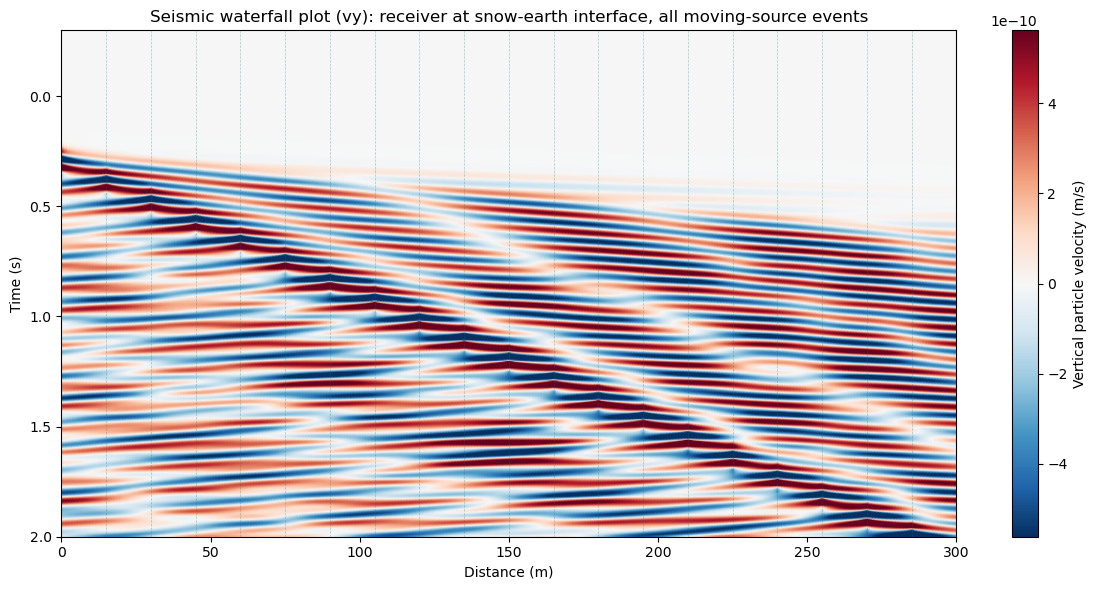

In [54]:
# Force inline display in case backend was set to Agg earlier
import matplotlib.pyplot as plt
from IPython.display import display

# Define receiver line at snow-earth interface (model coordinates)
y_surface = 3 * 2 / 3

# vel_2d_layered is already an xarray built from all events.
# Use direct selection instead of calling wavefield_output_to_xarray again.

# Resolve coordinate / dimension names robustly.
coords_set = set(vel_2d_layered.coords)
dims_set = set(vel_2d_layered.dims)

x_name = next((n for n in ["x", "X", "p0", "dim_0"] if n in coords_set or n in dims_set), None)
y_name = next((n for n in ["y", "Y", "p1", "dim_1"] if n in coords_set or n in dims_set), None)
t_name = next((n for n in ["t", "time"] if n in coords_set or n in dims_set), None)
c_name = next((n for n in ["c", "component"] if n in coords_set or n in dims_set), None)
e_name = next((n for n in ["event_index", "event", "source"] if n in coords_set or n in dims_set), None)

if x_name is None or y_name is None or t_name is None or c_name is None:
    raise ValueError(f"Could not resolve required dimensions. Found dims={vel_2d_layered.dims}, coords={list(vel_2d_layered.coords)}")

# Select vertical component (vy), then nearest y receiver line.
sg_vy = vel_2d_layered.isel({c_name: 1}).sel({y_name: y_surface}, method="nearest")

# Keep all moving-source events by reducing event dimension to a single stacked section.
if e_name is not None and e_name in sg_vy.dims:
    sg_vy_plot = sg_vy.mean(dim=e_name)
else:
    sg_vy_plot = sg_vy

# Ensure plotting order is (time, x)
sg_vy_plot = sg_vy_plot.transpose(t_name, x_name)

t_vals = sg_vy_plot[t_name].values
x_line = sg_vy_plot[x_name].values
data = sg_vy_plot.values

print("Using dimensions:", {"x": x_name, "y": y_name, "t": t_name, "c": c_name, "event": e_name})
print("t range:", t_vals[0], "->", t_vals[-1])
print("data shape:", data.shape)

# Clip colorscale (robust equivalent)
vmax = np.percentile(np.abs(data), 95)

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.pcolormesh(
    x_line,
    t_vals,
    data,
    shading="gouraud",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
ax.invert_yaxis()

# Mark all moving source positions
for x_src in x_positions:
    ax.axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

ax.set_xlabel("Distance (m)")
ax.set_ylabel("Time (s)")
ax.set_xlim(0, 300)
ax.set_title("Seismic waterfall plot (vy): receiver at snow-earth interface, all moving-source events")
plt.colorbar(im, ax=ax, label="Vertical particle velocity (m/s)")
plt.tight_layout()

# Display explicitly in notebook output
display(fig)
plt.close(fig)

In [55]:
# Build 2D animation directly from combined xarray (all moving-source events)
coords_set = set(vel_2d_layered.coords)
dims_set = set(vel_2d_layered.dims)

x_name = next((n for n in ["x", "X", "p0", "dim_0"] if n in coords_set or n in dims_set), None)
y_name = next((n for n in ["y", "Y", "p1", "dim_1"] if n in coords_set or n in dims_set), None)
t_name = next((n for n in ["t", "time"] if n in coords_set or n in dims_set), None)
c_name = next((n for n in ["c", "component"] if n in coords_set or n in dims_set), None)
e_name = next((n for n in ["event_index", "event", "source"] if n in coords_set or n in dims_set), None)

if x_name is None or y_name is None or t_name is None or c_name is None:
    raise ValueError(f"Could not resolve required dimensions. Found dims={vel_2d_layered.dims}, coords={list(vel_2d_layered.coords)}")

# Select vertical component.
vy = vel_2d_layered.isel({c_name: 1})

# Important: average over events can cancel signal out.
# Use RMS across events so all events contribute to amplitude.
if e_name is not None and e_name in vy.dims:
    vy = np.sqrt((vy ** 2).mean(dim=e_name))
    aggregated_mode = "RMS over events"
else:
    vy = np.abs(vy)
    aggregated_mode = "absolute amplitude (single event)"

# Reorder to (time, y, x) for imshow animation.
vy = vy.transpose(t_name, y_name, x_name)

x_vals = vy[x_name].values
y_vals = vy[y_name].values
t_vals = vy[t_name].values
frames_3d = np.asarray(vy.values, dtype=np.float64)  # shape: (n_t, n_y, n_x)

# Replace NaN/Inf before plotting and scaling.
frames_3d = np.nan_to_num(frames_3d, nan=0.0, posinf=0.0, neginf=0.0)

# Subsample time for faster animation generation.
t_start_idx = np.searchsorted(t_vals, 0.0)
N = 2
t_idx = np.arange(t_start_idx, frames_3d.shape[0], N)

# Robust scaling tuned for weak wavefields.
warmup = max(1, len(frames_3d) // 4)
vals = frames_3d[warmup:].ravel()
vals = vals[np.isfinite(vals)]
vals = vals[vals > 1e-15]

if vals.size == 0:
    raw_vmax = 1e-10
else:
    raw_vmax = float(np.percentile(vals, 99.5))

# Decrease vmax to boost contrast in low-amplitude arrivals.
contrast_gain = 0.25
vmax = max(raw_vmax * contrast_gain, 1e-12)

# Clip extreme spikes so colors are not dominated by few pixels.
frames_3d = np.clip(frames_3d, 0.0, 8.0 * vmax)

print("Using dimensions:", {"x": x_name, "y": y_name, "t": t_name, "c": c_name, "event": e_name})
print(f"Aggregation:     {aggregated_mode}")
print(f"x range:         {x_vals.min():.1f} -> {x_vals.max():.1f} m")
print(f"y range:         {y_vals.min():.2f} -> {y_vals.max():.2f} m")
print(f"t range:         {t_vals[0]:.3f} -> {t_vals[-1]:.3f} s")
print(f"frames to anim:  {len(t_idx)}")
print(f"raw_vmax:        {raw_vmax:.3e}")
print(f"vmax used:       {vmax:.3e}")


def run_animation():
    try:
        from matplotlib import colors

        fig, ax = plt.subplots(figsize=(14, 5))

        # Power-law normalization lifts weak amplitudes for visibility.
        norm = colors.PowerNorm(gamma=0.35, vmin=0.0, vmax=vmax)

        # Put shallow depth at top by reversing y in extent.
        im = ax.imshow(
            frames_3d[t_idx[0]],
            extent=[x_vals.min(), x_vals.max(), y_vals.max(), y_vals.min()],
            aspect="auto",
            cmap="RdBu_r",
            norm=norm,
            origin="upper",
            interpolation="nearest",
        )

        # Layer interfaces in model coordinates.
        ax.axhline(1.0, color="white", lw=1.2, linestyle="--", label="air-snow (1.0 m)")
        ax.axhline(2.0, color="lightgray", lw=1.2, linestyle="--", label="snow-soil (2.0 m)")

        ax.set_xlabel("x (m)")
        ax.set_ylabel("Depth (m)")
        ax.set_xlim(0, 300)
        ax.set_ylim(y_vals.max(), y_vals.min())
        ax.legend(loc="upper right", fontsize=8)
        plt.colorbar(im, ax=ax, label="Vertical particle velocity amplitude |vy| (m/s)", shrink=0.8)
        title = ax.set_title(f"Wavefield ({aggregated_mode}) - t = {t_vals[t_idx[0]]:.4f} s")
        plt.tight_layout()

        def update(frame_idx):
            ti = t_idx[frame_idx]
            im.set_data(frames_3d[ti])
            title.set_text(f"Wavefield ({aggregated_mode}) - t = {t_vals[ti]:.4f} s")
            return im, title

        ani = animation.FuncAnimation(
            fig,
            update,
            frames=len(t_idx),
            interval=40,
            blit=True,
        )

        # Pick a writer that is actually available.
        if animation.writers.is_available("ffmpeg"):
            print("Saving with ffmpeg...", flush=True)
            writer = animation.FFMpegWriter(
                fps=30,
                codec="libx264",
                extra_args=["-pix_fmt", "yuv420p"],
            )
            output_name = "wavefield_2d_all_events.mp4"
        else:
            print("ffmpeg not available, saving GIF with pillow...", flush=True)
            writer = animation.PillowWriter(fps=20)
            output_name = "wavefield_2d_all_events.gif"

        ani.save(
            output_name,
            writer=writer,
            dpi=120,
            progress_callback=lambda i, n: print(f"  saving frame {i}/{n}", flush=True) if i % 50 == 0 else None,
        )
        plt.close(fig)
        print(f"Done! Saved as {output_name}", flush=True)
    except Exception as exc:
        print(f"Animation failed: {exc}", flush=True)


thread = threading.Thread(target=run_animation)
thread.start()
print("Animation running in background thread.")
print("Check progress with: thread.is_alive()")

Using dimensions: {'x': 'x', 'y': 'y', 't': 't', 'c': 'c', 'event': 'event_index'}
Aggregation:     RMS over events
x range:         0.0 -> 300.0 m
y range:         0.00 -> 3.00 m
t range:         -0.300 -> 2.000 s
frames to anim:  204
raw_vmax:        5.337e-09
vmax used:       1.334e-09
Animation running in background thread.
Check progress with: thread.is_alive()


Sampling frequency: 203.9 Hz
Nyquist frequency:  101.9 Hz
ffmpeg not available, saving GIF with pillow...
  saving frame 0/204


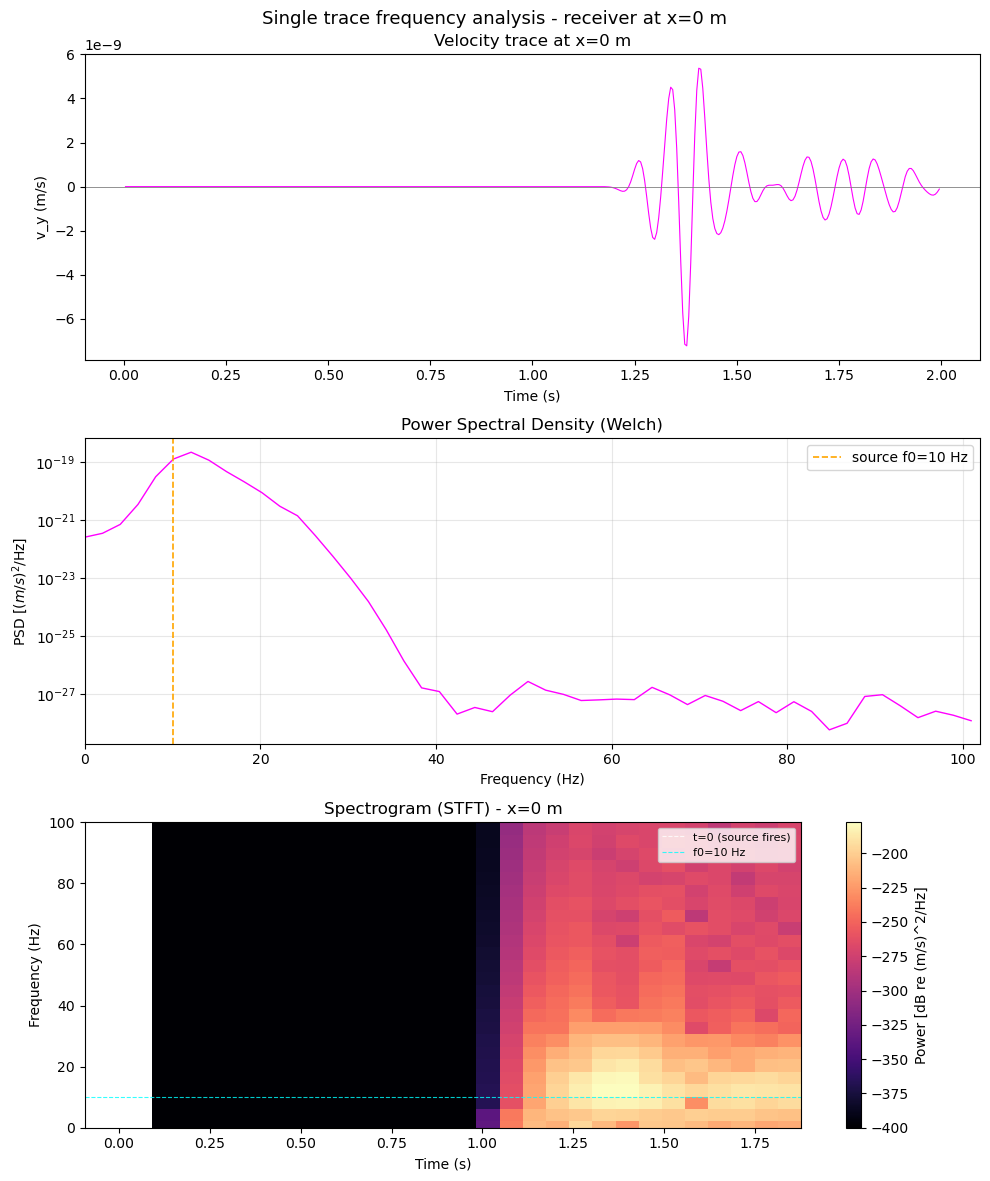

  saving frame 50/204
  saving frame 100/204
  saving frame 150/204
Animation failed: index 408 is out of bounds for axis 0 with size 407


In [56]:
# Extract a single receiver trace for frequency analysis.
# This is signed velocity data, so the time series should be shown with a zero line,
# while spectral quantities should use positive-only scales.
# Use one representative moving-source event to keep the trace 1D and physically interpretable.
trace_source = sg_vy
if "event_index" in trace_source.dims:
    representative_event = int(np.argmin(np.abs(x_positions - 150.0)))
    trace_source = trace_source.isel(event_index=representative_event)

trace_dim = next((d for d in ["x", "point"] if d in trace_source.dims), None)
if trace_dim is None:
    raise ValueError(f"Could not find a receiver coordinate in dims={trace_source.dims}")

trace = trace_source.sel({trace_dim: 0.0}, method="nearest").sel(t=slice(0, 2.0))
t_vals = trace.t.values
y_vals = trace.values

# dt and sampling frequency
dt = float(np.diff(t_vals).mean())
fs = 1.0 / dt
print(f"Sampling frequency: {fs:.1f} Hz")
print(f"Nyquist frequency:  {fs/2:.1f} Hz")

fig, axes = plt.subplots(3, 1, figsize=(10, 12))

# 1) Raw signed velocity trace
axes[0].plot(t_vals, y_vals, lw=0.8, color="magenta")
axes[0].axhline(0, color="gray", lw=0.6)
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("v_y (m/s)")
axes[0].set_title("Velocity trace at x=0 m")

# 2) Power Spectral Density (Welch)
# PSD is non-negative, so semilog-y is the right representation.
nperseg = min(1024, len(y_vals) // 4)
freqs_psd, psd = signal.welch(
    y_vals,
    fs=fs,
    nperseg=nperseg,
    noverlap=nperseg // 2,
    window="hann",
    scaling="density",
)
axes[1].semilogy(freqs_psd, psd, color="magenta", lw=1.0)
axes[1].axvline(10, color="orange", lw=1.2, linestyle="--", label="source f0=10 Hz")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel(r"PSD [$(m/s)^2$/Hz]")
axes[1].set_title("Power Spectral Density (Welch)")
axes[1].set_xlim(0, fs / 2)
axes[1].legend()
axes[1].grid(True, which="both", alpha=0.3)

# 3) Spectrogram (STFT)
# Spectrogram power is also positive, so use a log display and a sequential colormap.
nperseg_stft = min(512, len(y_vals) // 8)
freqs_stft, t_stft, Sxx = signal.spectrogram(
    y_vals,
    fs=fs,
    nperseg=nperseg_stft,
    noverlap=nperseg_stft * 3 // 4,
    window="hann",
    scaling="density",
)
Sxx_db = 10 * np.log10(Sxx + 1e-40)
im = axes[2].pcolormesh(
    t_stft,
    freqs_stft,
    Sxx_db,
    shading="auto",
    cmap="magma",
)
axes[2].axvline(0, color="white", lw=0.8, linestyle="--", alpha=0.8, label="t=0 (source fires)")
axes[2].axhline(10, color="cyan", lw=0.8, linestyle="--", alpha=0.8, label="f0=10 Hz")
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("Frequency (Hz)")
axes[2].set_title("Spectrogram (STFT) - x=0 m")
axes[2].set_ylim(0, min(100, fs / 2))
axes[2].legend(loc="upper right", fontsize=8)
fig.colorbar(im, ax=axes[2], label="Power [dB re (m/s)^2/Hz]")

plt.suptitle("Single trace frequency analysis - receiver at x=0 m", fontsize=13)
plt.tight_layout()

# Force notebook display even with a non-interactive backend.
from IPython.display import display
display(fig)
plt.close(fig)